In [ ]:
#STEP 5 - Python Analysis

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [15]:
#TASK 1- Load dataset
file_path=r"C:\Users\Abina\OneDrive\Desktop\DATASET- Retail Sales superstore.csv"
df=pd.read_csv(file_path)
print("Rows:",len(df))
print("Columns:",len(df.columns))

Rows: 9994
Columns: 21


In [12]:
#first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [13]:
#TASK 2- Structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [14]:
#TASK 3- missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [17]:
#TASK 4- Convert mixed date formats correctly
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

# Check the result
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [18]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18
5,2014-06-09,2014-06-14
6,2014-06-09,2014-06-14
7,2014-06-09,2014-06-14
8,2014-06-09,2014-06-14
9,2014-06-09,2014-06-14


In [21]:
#TASK 5- calculate important business KPI's
#1.TOTAL SALES
total_sales=df['Sales'].sum()
print("Total Sales:",round(total_sales,2))

Total Sales: 2297200.86


In [22]:
#2.TOTAL PROFIT 
total_profit = df['Profit'].sum()
print("Total Profit:", round(total_profit, 2))

Total Profit: 286397.02


In [24]:
#3.TOTAL ORDERS
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


In [25]:
#4.AVERAGE SALES
average_sales = df['Sales'].mean()
print("Average Sales:", round(average_sales, 2))

Average Sales: 229.86


In [30]:
#TASK 6- Category Analysis
#1. sales by category
category_sales=(df.groupby('Category')['Sales']
    .sum()
    .round(2)
    .sort_values(ascending=False))
category_sales

Category
Technology         836154.03
Furniture          741999.80
Office Supplies    719047.03
Name: Sales, dtype: float64

In [31]:
#2. Profit by Category
category_profit = (df.groupby('Category')['Profit']
    .sum()
    .round(2)
    .sort_values(ascending=False))
category_profit

Category
Technology         145454.95
Office Supplies    122490.80
Furniture           18451.27
Name: Profit, dtype: float64

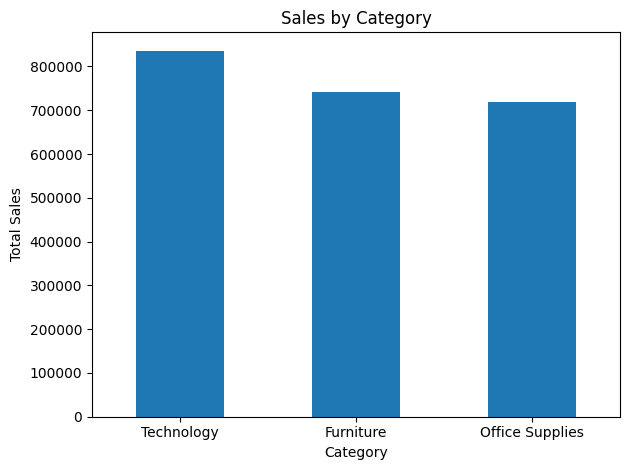

In [32]:
#3. Category Sales Chart
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

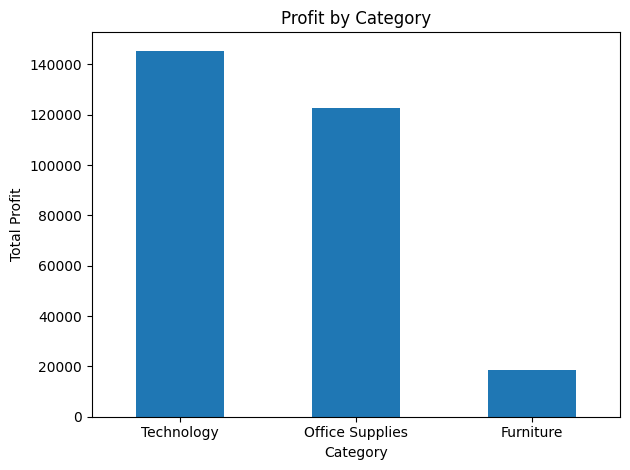

In [33]:
#4. Category Profit Chart
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
#TASK 7- Region Analysis
#1. Sales by Region
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .round(2)
    .sort_values(ascending=False))
region_sales

Region
West       725457.82
East       678781.24
Central    501239.89
South      391721.90
Name: Sales, dtype: float64

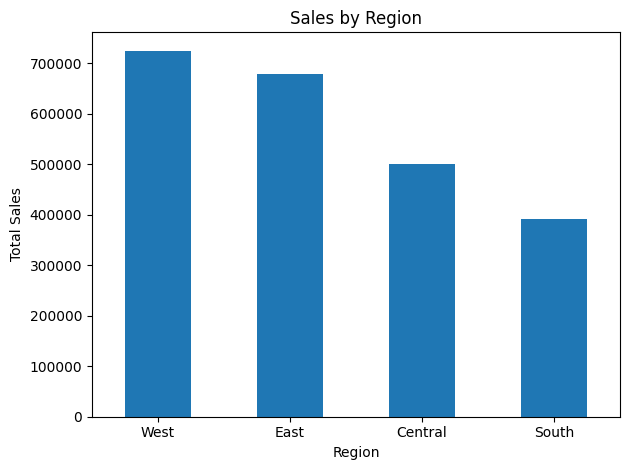

In [36]:
#2. Create the chart
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
#TASK 8- Yearly Sales Analysis
#1. Calculate yearly sales
yearly_sales = (df.groupby(df['Order Date'].dt.year)['Sales']
    .sum()
    .round(2)
    .sort_values(ascending=False))
yearly_sales

Order Date
2017    733215.26
2016    609205.60
2014    484247.50
2015    470532.51
Name: Sales, dtype: float64

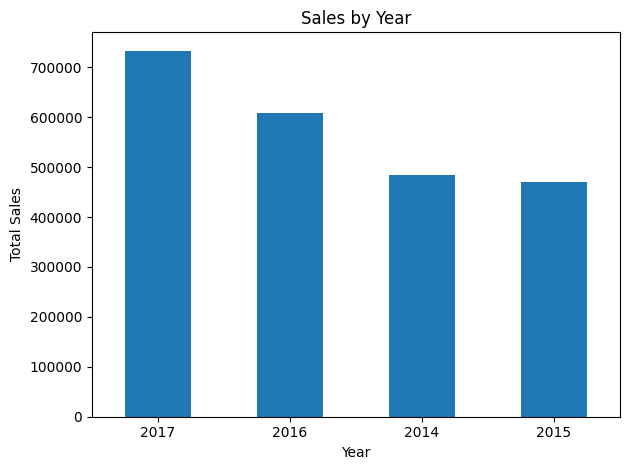

In [39]:
#2. Create the chart
yearly_sales.plot(kind='bar')
plt.title('Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
#TASK 9- Top 5 Products by Sales
#Calculate
top_products = (df.groupby('Product Name')['Sales']
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .head(5))
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.58
GBC DocuBind TL300 Electric Binding System                                     19823.48
Name: Sales, dtype: float64

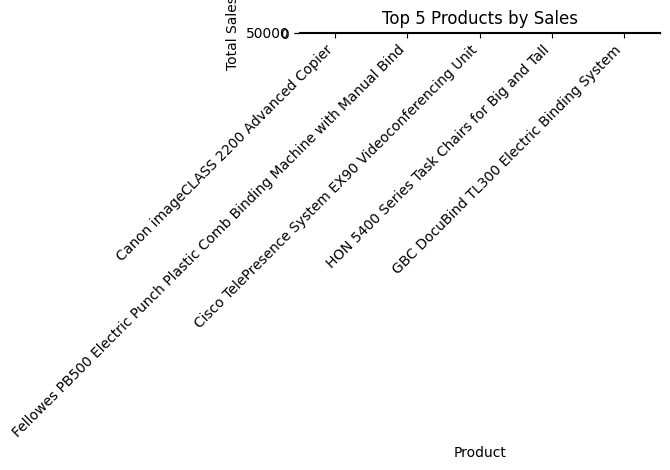

In [44]:
#Chart
top_products.plot(kind='bar')
plt.title('Top 5 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
#TASK 10- Top Customers by Sales
#Calculate
top_customers = (df.groupby('Customer Name')['Sales']
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .head(5))
top_customers

Customer Name
Sean Miller      25043.05
Tamara Chand     19052.22
Raymond Buch     15117.34
Tom Ashbrook     14595.62
Adrian Barton    14473.57
Name: Sales, dtype: float64

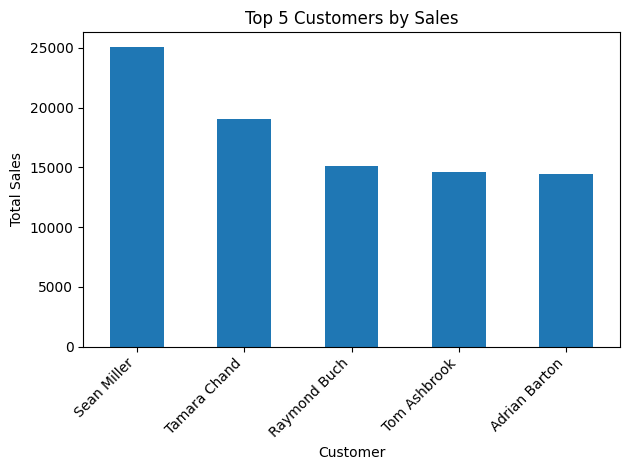

In [46]:
#chart
top_customers.plot(kind='bar')
plt.title('Top 5 Customers by Sales')
plt.xlabel('Customer')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [47]:
#TASK 11- Discount vs Profit
#Calculate
discount_profit = (df.groupby('Discount')['Profit']
    .sum()
    .round(2))
discount_profit

Discount
0.00    320987.60
0.10      9029.18
0.15      1418.99
0.20     90337.31
0.30    -10369.28
0.32     -2391.14
0.40    -23057.05
0.45     -2493.11
0.50    -20506.43
0.60     -5944.66
0.70    -40075.36
0.80    -30539.04
Name: Profit, dtype: float64

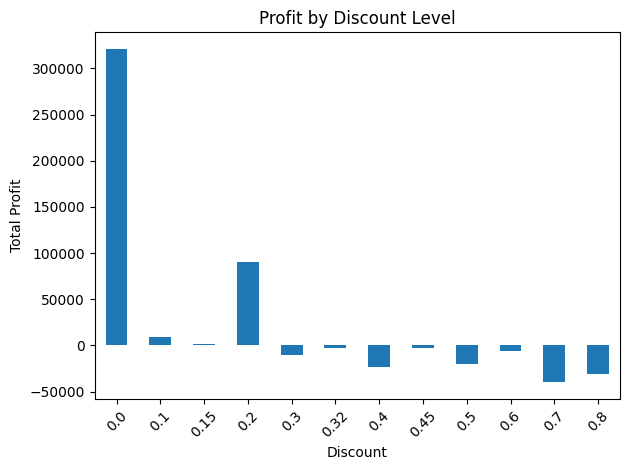

In [48]:
#chart
discount_profit.plot(kind='bar')
plt.title('Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()